---
## 📊  Data Loading & Augmentation

In [3]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("nilesh789/eurosat-rgb")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'eurosat-rgb' dataset.
Dataset downloaded to: /kaggle/input/eurosat-rgb


In [13]:
import tifffile as tiff
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import os
import tensorflow as tf

import kagglehub
path = kagglehub.dataset_download("nilesh789/eurosat-rgb")
DATA_DIR = path + "/2750"

TARGET_SIZE = (64, 64)

def load_eurosat_ms_rgb(data_dir):
    images = []
    labels = []

    class_names = sorted(os.listdir(data_dir))
    class_map = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        print(f"🔄 Loading and processing class: {class_name} ...")
        for img_name in os.listdir(class_path):
            if img_name.endswith('.jpg') or img_name.endswith('.jpeg'):
                img_path = os.path.join(class_path, img_name)
                img_rgb = Image.open(img_path).resize(TARGET_SIZE)  # resize here
                img_rgb = np.array(img_rgb)

                if img_rgb.shape[-1] == 3:
                    img_rgb = img_rgb.astype('float32') / 255.0
                    images.append(img_rgb)
                    labels.append(class_map[class_name])
                else:
                    print(f"⚠️ Warning: Skipping image {img_name} due to {img_rgb.shape[-1]} channels instead of 3.")

    return np.array(images), np.array(labels), class_names

print("🚀 Starting dataset processing...")
X, y, CLASS_NAMES = load_eurosat_ms_rgb(DATA_DIR)
print(f"✅ Successfully loaded {len(X)} images as RGB arrays!")

NUM_CLASSES = len(CLASS_NAMES)
SEED = 42

y = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"\n📈 Training Set Shapes: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"📉 Validation Set Shapes: X_val={X_val.shape}, y_val={y_val.shape}")


Using Colab cache for faster access to the 'eurosat-rgb' dataset.
🚀 Starting dataset processing...
🔄 Loading and processing class: AnnualCrop ...
🔄 Loading and processing class: Forest ...
🔄 Loading and processing class: HerbaceousVegetation ...
🔄 Loading and processing class: Highway ...
🔄 Loading and processing class: Industrial ...
🔄 Loading and processing class: Pasture ...
🔄 Loading and processing class: PermanentCrop ...
🔄 Loading and processing class: Residential ...
🔄 Loading and processing class: River ...
🔄 Loading and processing class: SeaLake ...
✅ Successfully loaded 27000 images as RGB arrays!

📈 Training Set Shapes: X_train=(21600, 64, 64, 3), y_train=(21600, 10)
📉 Validation Set Shapes: X_val=(5400, 64, 64, 3), y_val=(5400, 10)


---
## 🏗️  Model Architecture — VGG19

In [14]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW

def compile_model(model_name, input_shape, num_classes, optimizer, fine_tune=None):
    """
    Build & compile VGG19 transfer learning model.
    fine_tune=None  → freeze entire base (Phase 1)
    fine_tune=0     → unfreeze all layers (Phase 2)
    fine_tune=N     → unfreeze from layer N onward
    """
    base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)

    if fine_tune is None:
        base.trainable = False
    elif fine_tune == 0:
        base.trainable = True
    else:
        base.trainable = True
        for layer in base.layers[:fine_tune]:
            layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['categorical_accuracy'])
    return model

INPUT_SHAPE = (64, 64, 3)  # increased from 64

vgg19_model = compile_model('VGG19', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-3), fine_tune=None)
vgg19_model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,085,770 (80.44 MB)

 Trainable params: 1,058,314 (4.04 MB)

 Non-trainable params: 20,027,456 (76.40 MB)

---
## ⚙️  Callbacks

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

BATCH_SIZE = 32  # increased from 32

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
test_generator  = test_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False, seed=SEED)

N_STEPS     = len(X_train) // BATCH_SIZE
N_VAL_STEPS = len(X_val)  // BATCH_SIZE

checkpoint = ModelCheckpoint(
    filepath='../working/model.weights.best.keras',
    monitor='val_categorical_accuracy', save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_categorical_accuracy', patience=15,
    restore_best_weights=True, mode='max'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_categorical_accuracy', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

print(f'Steps/epoch: {N_STEPS} | Val steps: {N_VAL_STEPS}')


Steps/epoch: 675 | Val steps: 168


---
## 🚀  Phase 1 — Train Head Only (Base Frozen)

In [16]:
vgg19_history_p1 = vgg19_model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=80,               # increased from 50
    callbacks=[early_stop, checkpoint],
    validation_data=(X_val, y_val)
)
print('\n✅ Phase 1 done!')


Epoch 1/80
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.6429 - loss: 1.1395
Epoch 1: val_categorical_accuracy improved from None to 0.76407, saving model to ../working/model.weights.best.keras

Epoch 1: finished saving model to ../working/model.weights.best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - categorical_accuracy: 0.7034 - loss: 0.9178 - val_categorical_accuracy: 0.7641 - val_loss: 0.7318
Epoch 2/80
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.7660 - loss: 0.6822
Epoch 2: val_categorical_accuracy did not improve from 0.76407
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - categorical_accuracy: 0.7698 - loss: 0.6754 - val_categorical_accuracy: 0.7619 - val_loss: 0.6860
Epoch 3/80
673/675 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.7894 - loss: 0.6053
Epoch 3: val_categorical_accuracy did not improve from 0.76407
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - categorical_accuracy: 0.7890 - loss: 0.6074 - val_categori

---
##  Phase 2 — Fine-Tuning (All Layers Unfrozen)

In [17]:
vgg19_model = compile_model('VGG19', INPUT_SHAPE, NUM_CLASSES,
                            AdamW(learning_rate=1e-5, weight_decay=1e-4), fine_tune=10)  # improved from 15

vgg19_model.load_weights('../working/model.weights.best.keras')
vgg19_history = vgg19_model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=100,
    callbacks=[early_stop, checkpoint, reduce_lr],
    validation_data=(X_val, y_val)
)
print('\n✅ Phase 2 done!')


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - categorical_accuracy: 0.8524 - loss: 0.4269
Epoch 1: val_categorical_accuracy improved from 0.86370 to 0.87685, saving model to ../working/model.weights.best.keras

Epoch 1: finished saving model to ../working/model.weights.best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - categorical_accuracy: 0.8693 - loss: 0.3866 - val_categorical_accuracy: 0.8769 - val_loss: 0.3773 - learning_rate: 1.0000e-05
Epoch 2/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - categorical_accuracy: 0.9100 - loss: 0.2569
Epoch 2: val_categorical_accuracy improved from 0.87685 to 0.91556, saving model to ../working/model.weights.best.keras

Epoch 2: finished saving model to ../working/model.weights.best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - categorical_accuracy: 0.9100 - loss: 0.2589 - val_categorical_accuracy: 0.9156 - val_loss: 0.2527 - learning_rate: 1.0000e-05
Epoch 3/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - categorical_accuracy

---
##  Training Curves

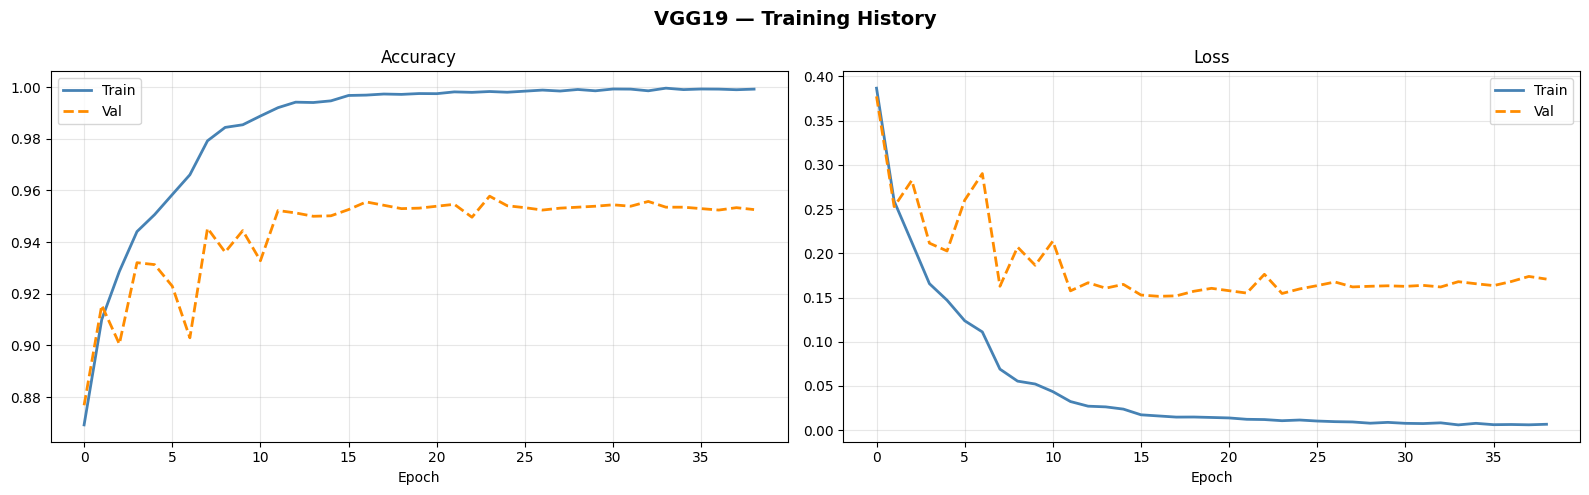

In [18]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('VGG19 — Training History', fontsize=14, fontweight='bold')

    ax1.plot(history.history['categorical_accuracy'],     label='Train', color='steelblue', lw=2)
    ax1.plot(history.history['val_categorical_accuracy'], label='Val',   color='darkorange', lw=2, ls='--')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', color='steelblue', lw=2)
    ax2.plot(history.history['val_loss'], label='Val',   color='darkorange', lw=2, ls='--')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../working/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(vgg19_history)

---
##  Evaluation

169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step
Classification Report
                      precision    recall  f1-score      support
AnnualCrop             0.956449  0.951667  0.954052   600.000000
Forest                 0.989983  0.988333  0.989158   600.000000
HerbaceousVegetation   0.951178  0.941667  0.946399   600.000000
Highway                0.940928  0.892000  0.915811   500.000000
Industrial             0.970179  0.976000  0.973081   500.000000
Pasture                0.918072  0.952500  0.934969   400.000000
PermanentCrop          0.920078  0.944000  0.931885   500.000000
Residential            0.975369  0.990000  0.982630   600.000000
River                  0.947581  0.940000  0.943775   500.000000
SeaLake                0.986667  0.986667  0.986667   600.000000
accuracy               0.957778  0.957778  0.957778     0.957778
macro avg              0.955648  0.956283  0.955843  5400.000000
weighted avg           0.957852  0.957778  0.957705  5400.000000

✅  TOTAL TEST ACCURACY: 9

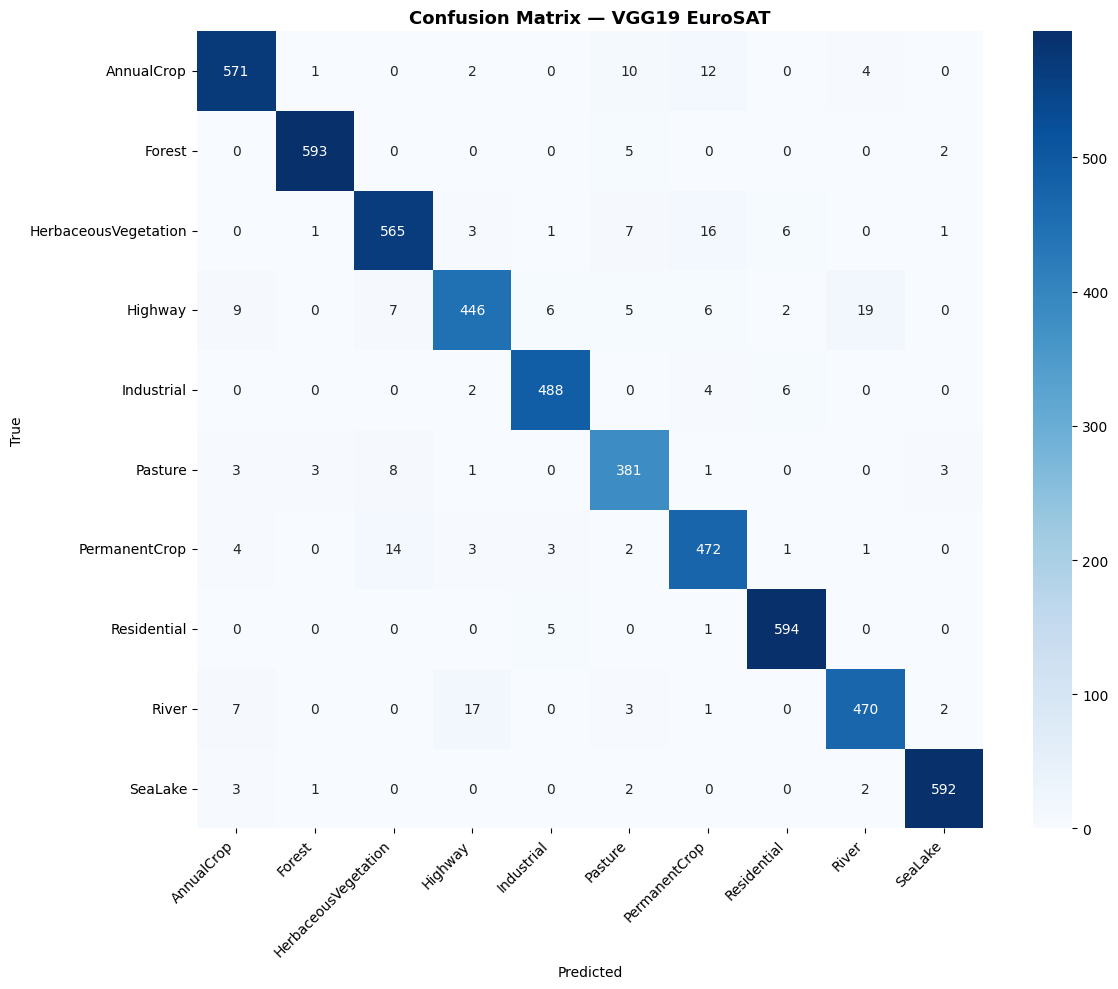

,precision,recall,f1-score,support
AnnualCrop,0.956449,0.951667,0.954052,600.000000
Forest,0.989983,0.988333,0.989158,600.000000
HerbaceousVegetation,0.951178,0.941667,0.946399,600.000000
Highway,0.940928,0.892000,0.915811,500.000000
Industrial,0.970179,0.976000,0.973081,500.000000
Pasture,0.918072,0.952500,0.934969,400.000000
PermanentCrop,0.920078,0.944000,0.931885,500.000000
Residential,0.975369,0.990000,0.982630,600.000000
River,0.947581,0.940000,0.943775,500.000000
SeaLake,0.986667,0.986667,0.986667,600.000000


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def display_results(true_classes, predicted_classes, class_names):
    print('=' * 60)
    print('Classification Report')
    print('=' * 60)
    report = classification_report(true_classes, predicted_classes,
                                   target_names=list(class_names), output_dict=True)
    prf = pd.DataFrame(report).transpose()
    print(prf.to_string())

    # ── Total Accuracy ──────────────────────────────────────
    total_acc = accuracy_score(true_classes, predicted_classes)
    print('\n' + '=' * 60)
    print(f'✅  TOTAL TEST ACCURACY: {total_acc * 100:.2f}%')
    print('=' * 60)

    cm = confusion_matrix(true_classes, predicted_classes)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title('Confusion Matrix — VGG19 EuroSAT', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../working/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return prf, cm

vgg19_model.load_weights('../working/model.weights.best.keras')

class_indices = dict(enumerate(CLASS_NAMES))

test_generator.reset()
predictions       = vgg19_model.predict(test_generator, steps=len(test_generator), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = np.argmax(y_val, axis=1)

prf, conf_mat = display_results(true_classes, predicted_classes, list(class_indices.values()))
prf


---
##  Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step


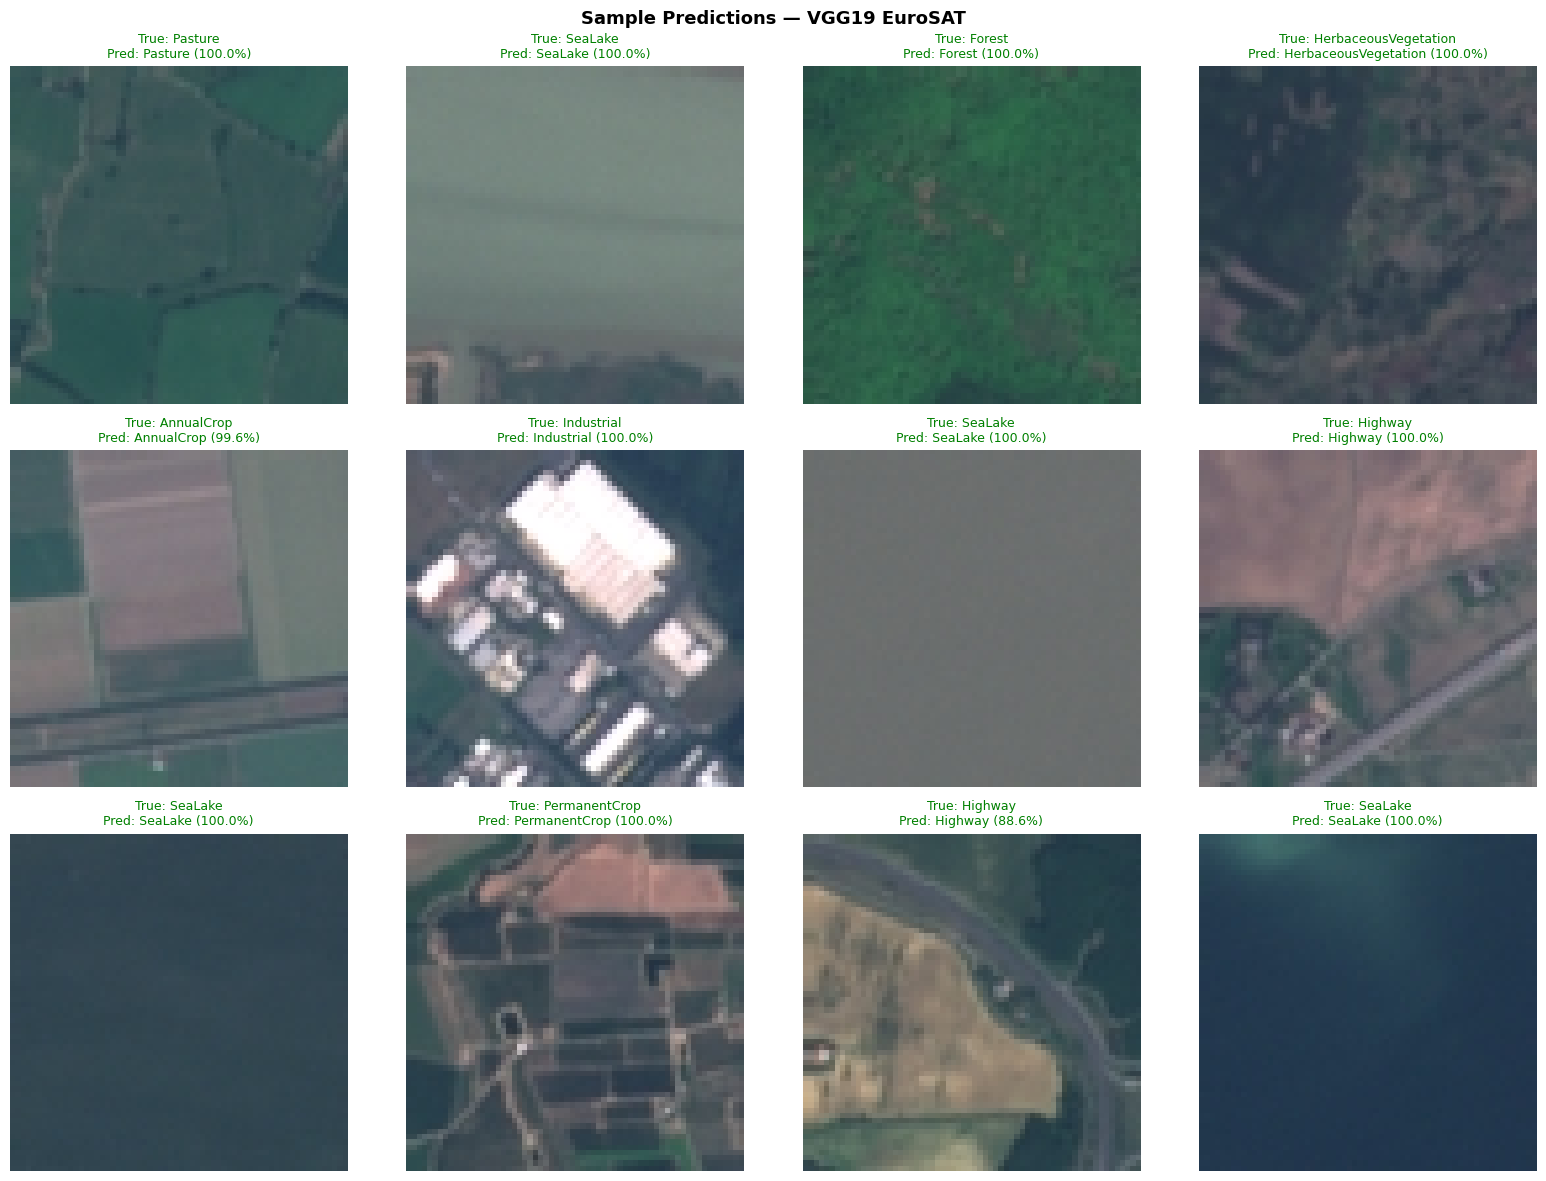

In [20]:
def show_predictions(model, generator, class_indices, n=12):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Sample Predictions — VGG19 EuroSAT', fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(images[i])
            true_lbl = class_indices[np.argmax(labels[i])]
            pred_lbl = class_indices[np.argmax(preds[i])]
            conf     = np.max(preds[i]) * 100
            color    = 'green' if true_lbl == pred_lbl else 'red'
            ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)', color=color, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('../working/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(vgg19_model, test_generator, class_indices)

---
##  Save Model

In [21]:
vgg19_model.save('../working/vgg19_eurosat.h5')
print('✅ Model saved!')

for f in sorted(os.listdir('../working')):
    size = os.path.getsize(f'../working/{f}') / 1e6
    print(f'  {f}  ({size:.1f} MB)')

✅ Model saved!
  confusion_matrix.png  (0.1 MB)
  model.weights.best.keras  (239.3 MB)
  sample_predictions.png  (0.2 MB)
  training_curves.png  (0.1 MB)
  vgg19_eurosat.h5  (239.3 MB)
